In [1]:
import numpy as np
from hodalpt.sims import alpt

In [2]:
import matplotlib.pyplot as plt

In [4]:
Omega_m, Omega_b, h, ns, s8 = 0.3175, 0.049, 0.6711, 0.9624, 0.834

# check CAMB power spectrum

In [5]:
k, zs, Pkmm = alpt.camb_Pkmm0(Omega_m, Omega_b, h, ns, s8)

In [7]:
_k, _Pkmm = np.loadtxt('/Users/ch54662/Downloads/fiducial_LR/0/ICs/CAMB_matterpow_0.dat', unpack=True)

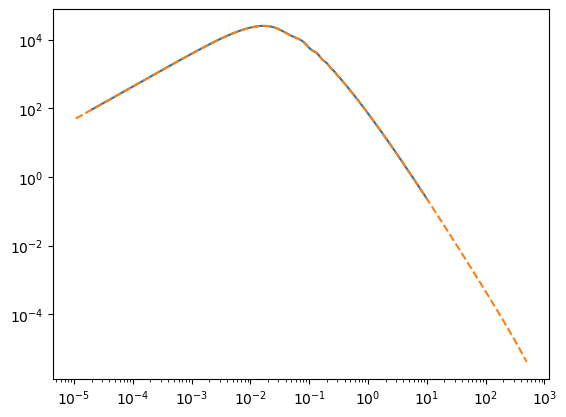

In [8]:
plt.loglog(k, Pkmm[0])
plt.loglog(_k, _Pkmm, ls='--')
plt.show()

# check 2LPT initial conditions

In [18]:
delta = alpt.generate_IC(Omega_m, Omega_b, h, ns, s8, 1000., 256, 5, ic_dir='/Users/ch54662/projects/hodalpt/src/hodalpt/sims/ICs', Nmesh=512,
                Nsample=256, silent=False)

Computing 2LPT IC
found 400 pairs of values in input spectrum table

Normalization of spectrum in file:  Sigma8 = 0.833103
Normalization adjusted to  Sigma8=0.834   (Normfac=1.00216)

Task=0 Local_nx=512

allocated 1028 Mbyte on Task 0

reading Lagrangian glass file...
reading '/Users/ch54662/projects/hodalpt/src/hodalpt/sims/GLASS/dummy_glass_dmonly_64.dat' with 262144 particles

Nglass= 262144

16777216 particles on task=0  (slabs=512)

Total number of particles  = 0016777216


start computing displacement fields...
vel_prefac= 7.21243, vel_prefac2= 14.4249,  hubble_a=81.5994 fom=0.999999 
Phase shift = 0.0000000


allocated 3090.02 Mbyte on Task 0

starting axes=3...
Done Zeldovich.

allocated 1030.01 Mbyte on Task 0

allocated 1030.01 Mbyte on Task 0

allocated 1030.01 Mbyte on Task 0

allocated 1030.01 Mbyte on Task 0

allocated 1030.01 Mbyte on Task 0

allocated 1030.01 Mbyte on Task 0
Fourier transforming displacement gradient...Done.
Fourier transforming second order source...D

In [10]:
delta1 = alpt._make_ics_quijote('/Users/ch54662/Downloads/fiducial_LR/0/ICs', 1000, 256)

In [11]:
delta

array([ 0.00750037, -0.02211047, -0.0184504 , ..., -0.00826723,
       -0.00619284, -0.01048528], shape=(16777216,))

In [12]:
delta1

array([ 0.024128  ,  0.02093112,  0.00814403, ..., -0.02037147,
        0.00037876,  0.01478151], shape=(16777216,))

In [25]:
def MAS_correction(x, MAS_index):
    if x == 0.0:
        return 1.0
    return (x / np.sin(x)) ** MAS_index

def Pk(delta, BoxSize): 
    delta = np.asarray(delta, dtype=np.float32)
    if delta.ndim != 3 or delta.shape[0] != delta.shape[1] or delta.shape[1] != delta.shape[2]:
        raise ValueError("delta must have shape (dims, dims, dims)")

    dims = delta.shape[0]
    middle = dims // 2

    MAS_index = 2

    kF = 2.0 * np.pi / BoxSize
    middle = dims // 2
    kN = middle * kF
    kmax_par = middle
    kmax_per = int(np.sqrt(middle**2 + middle**2))
    kmax = int(np.sqrt(middle**2 + middle**2 + middle**2))

    # rFFT of real field: output shape (dims, dims, middle+1)
    delta_k = np.fft.rfftn(delta).astype(np.complex64, copy=False)

    # 1D arrays
    k1D = np.zeros(kmax_par + 1, dtype=np.float64)
    Pk1D = np.zeros(kmax_par + 1, dtype=np.float64)
    Nmodes1D = np.zeros(kmax_par + 1, dtype=np.float64)

    prefact = np.pi / dims

    for kxx in range(dims):
        kx = kxx - dims if kxx > middle else kxx
        mas_x = MAS_correction(prefact * kx, MAS_index)

        for kyy in range(dims):
            ky = kyy - dims if kyy > middle else kyy
            mas_y = MAS_correction(prefact * ky, MAS_index)

            for kzz in range(middle + 1):
                kz = kzz - dims if kzz > middle else kzz
                mas_z = MAS_correction(prefact * kz, MAS_index)

                # independent-mode selection
                if kz == 0 or (kz == middle and dims % 2 == 0):
                    if kx < 0:
                        continue
                    elif kx == 0 or (kx == middle and dims % 2 == 0):
                        if ky < 0:
                            continue

                k = np.sqrt(kx * kx + ky * ky + kz * kz)
                k_index = int(k)

                k_par = kz
                k_per = int(np.sqrt(kx * kx + ky * ky))

                mu = 0.0 if k == 0 else k_par / k
                mu2 = mu * mu

                if k_par < 0:
                    k_par = -k_par

                mas_factor = mas_x * mas_y * mas_z
                dk = delta_k[kxx, kyy, kzz] * mas_factor

                real = dk.real
                imag = dk.imag
                delta2 = real * real + imag * imag

                # match original phase definition
                phase = np.arctan2(real, np.sqrt(delta2)) if delta2 > 0 else 0.0

                # 1D P(k_parallel), only modes with |k| <= kN in grid units
                if k <= middle:
                    k1D[k_par] += k_par
                    Pk1D[k_par] += delta2
                    Nmodes1D[k_par] += 1.0


    k1D = k1D[1:]
    Pk1D = Pk1D[1:]
    Nmodes1D = Nmodes1D[1:]

    valid_1d = Nmodes1D > 0
    for i in range(len(k1D)):
        if not valid_1d[i]:
            continue
        Pk1D[i] = Pk1D[i] * (BoxSize / dims**2) ** 3
        k1D[i] = (k1D[i] / Nmodes1D[i]) * kF
        kmaxper = np.sqrt(max(0.0, kN**2 - k1D[i] ** 2))
        Pk1D[i] = Pk1D[i] * (np.pi * kmaxper**2 / Nmodes1D[i]) / (2.0 * np.pi) ** 2

    return k1D, Pk1D, Nmodes1D

In [27]:
k0, pk0, _ = Pk(delta.reshape((256, 256, 256)), 1000)
k1, pk1, _ = Pk(delta1.reshape((256, 256, 256)), 1000)

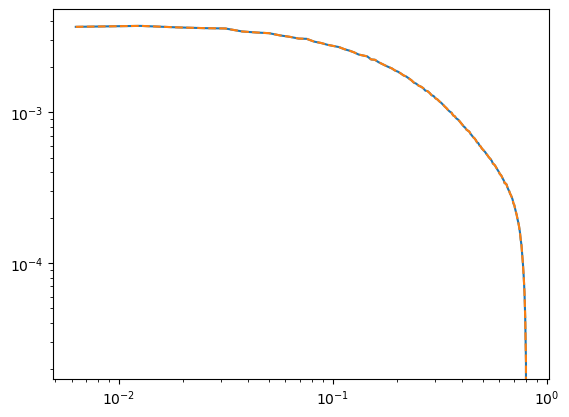

In [28]:
plt.loglog(k0, pk0)
plt.loglog(k1, pk1, ls='--')

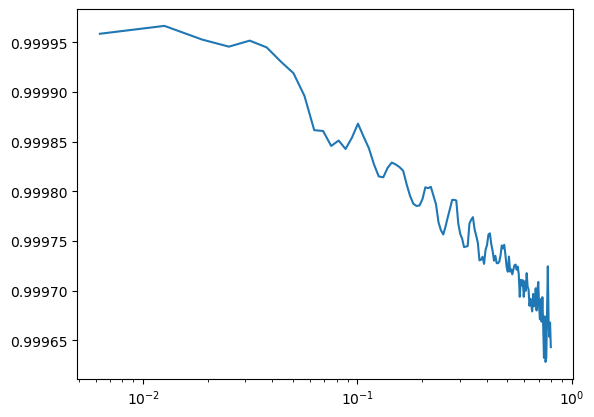

In [29]:
plt.plot(k0, pk0/pk1)
plt.xscale('log')